In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Hypothesis testing

Hypothesis tests follow the same grammar as confidence intervals, with an added
`hypothesize()` step that defines the null world, and `generate()` that simulates
from it.

## Two groups: a permutation test

The classic "promotions" experiment — does the (perceived) gender on a résumé
change the promotion rate?

In [2]:
import moderndive as md
from moderndive import specify, observe, get_p_value, visualize, shade_p_value

promotions = md.load_promotions()

# Observed difference in promotion proportions, male − female
obs = observe(
    promotions, formula="decision ~ gender", success="promoted",
    stat="diff in props", order=("male", "female"),
)   # ≈ 0.292

# Null: gender is independent of the decision → permute the labels
null = (
    specify(promotions, formula="decision ~ gender", success="promoted")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=42)
    .calculate(stat="diff in props", order=("male", "female"))
)

get_p_value(null, obs_stat=obs, direction="right")   # ≈ 0.025

p_value
f64
0.025


## Shade the p-value

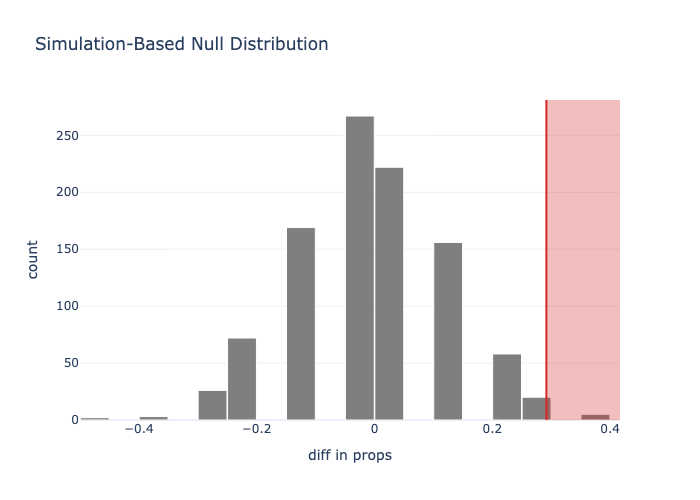

In [3]:
visualize(null) + shade_p_value(obs_stat=obs, direction="right")

`direction` is one of `"right"`/`"greater"`, `"left"`/`"less"`, or `"two-sided"`.
The two-sided shading mirrors the observed statistic about 0.

## One mean / one proportion (point null)

Use a `"point"` null with bootstrap resampling, supplying the hypothesized value:

In [4]:
age = md.load_age_at_marriage()

obs_t = observe(age, response="age", stat="t", null="point", mu=23)

null_t = (
    specify(age, response="age")
    .hypothesize(null="point", mu=23)
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="t")
)
get_p_value(null_t, obs_stat=obs_t, direction="two-sided")

p_value
f64
0.0


For a one-proportion test you can also *simulate* draws directly:

In [5]:
import polars as pl

coins = pl.DataFrame({"flip": ["heads"] * 30 + ["tails"] * 70})

null_p = (
    specify(coins, response="flip", success="heads")
    .hypothesize(null="point", p=0.5)
    .generate(reps=1000, type="draw", seed=1)   # "simulate" is an alias
    .calculate(stat="prop")
)

## Available statistics

`calculate(stat=...)` supports the full infer vocabulary: `"mean"`, `"median"`,
`"sum"`, `"sd"`, `"prop"`, `"count"`, `"diff in means"`, `"diff in medians"`,
`"diff in props"`, `"ratio of means"`, `"ratio of props"`, `"odds ratio"`,
`"slope"`, `"correlation"`, `"t"`, `"z"`, `"F"`, `"Chisq"`, plus any custom
callable `stat(response, explanatory) -> float`.

```{seealso}
Prefer a one-line classical test? See the tidy wrappers in {doc}`theory-based`
(`t_test`, `prop_test`, `chisq_test`).
```